<a href="https://colab.research.google.com/github/kyambuludi95/2020_11_PythonWeekend/blob/main/Week02/src/HDCGD_CP_W2_E2_PT2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🧠 Trabajo 2: Predicción del titanic
Regresión logística y K-NN

## 📋 Información del Proyecto
- Autores:
  - CARRERA DIAZ CHRISTIAN JAVIER
  - KEVIN YITZHACK AMBULUDI PATIÑO
  - ROMEL MICHAEL CERNA PACHECO
- Versión: 1.0.0
- Licencia: MIT


🎯 Introducción:

Esta práctica tiene el objetivo de realizar la predicción del tipo de cáncer de mama (maligno=1, benigno=0) utilizando los algoritmos de clasificación revisados de regresión logística y K-NN, así como realizar la evaluación del rendimiento de los algoritmos usando las métricas y gráficas respectivas. Al finalizar la práctica, los maestrantes podrán entender y manipular  adecuadamente los diferentes parámetros e hiperparámetros de los algoritmos estudiados.

**🌍 Contexto del trabajo**

Utilice el dataset de cáncer de mama (Diagnostic Wisconsin Breast Cancer
Database, WBCD) donde tenemos los datos de 569 mujeres. Cada mujer está
descrita por 32 atributos. El primero es un identificador, el segundo el tipo de
cáncer (Maligno o Benigno) y el resto son el resultado de otros análisis clínicos. Se pretende aprender el tipo de cáncer de mama (maligno=1, benigno=0). En este conjunto de datos la distribución de clases es: 357 benignos y 212 malignos.

# 🏗️ Preparación de datos para el entrenamiento:

*******************************************************************************

## 🔗 Enlaces del Dataset que se usaran

La información usada es un recurso compartido por parte de nuestro tutor para realizar la practiva de este proyecto.

## 🚀 Descarga del dataset

El dataset contiene información de los tripulantes del titanic y toda la información sobre los pasajeros.

📥 Este código instala la libreria del sitio donde descargaremos el dataset:

In [1]:
 # importacion de la libreria os que permite interactuar con el sistema operativo (archivos y rutas)

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Define el nombre del archivo comprimido que se descargará
population_file_path = 'titanic.csv'

# Descarga el archivo CSV

if not os.path.exists(population_file_path):
  !wget --timeout=15 --tries=2 'https://raw.githubusercontent.com/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/refs/heads/main/Week01/doc/titanic.csv' -O '{population_file_path}'

# Leer el archivo CSV
df = pd.read_csv(population_file_path)

# Ver las primeras filas del conjunto de datos
print(df.head())

# Conteo de datos en el dataset
df.value_counts()

--2026-05-23 16:33:59--  https://raw.githubusercontent.com/ChrisJavier/UIDE_2-WorkGroupDataScienceTools/refs/heads/main/Week01/doc/titanic.csv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.109.133, 185.199.110.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 60302 (59K) [text/plain]
Saving to: ‘titanic.csv’

titanic.csv         100%[===================>]  58.89K  --.-KB/s    in 0.006s  

2026-05-23 16:33:59 (9.26 MB/s) - ‘titanic.csv’ saved [60302/60302]

   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cu

,,,,,,,,,,,,count
PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,
2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Thayer)",female,38.0,1,0,PC 17599,71.2833,C85,C,1
4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,1
7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S,1
11,1,3,"Sandstrom, Miss. Marguerite Rut",female,4.0,1,1,PP 9549,16.7000,G6,S,1
12,1,1,"Bonnell, Miss. Elizabeth",female,58.0,0,0,113783,26.5500,C103,S,1
...,...,...,...,...,...,...,...,...,...,...,...,...
872,1,1,"Beckwith, Mrs. Richard Leonard (Sallie Monypeny)",female,47.0,1,1,11751,52.5542,D35,S,1
873,0,1,"Carlsson, Mr. Frans Olof",male,33.0,0,0,695,5.0000,B51 B53 B55,S,1
880,1,1,"Potter, Mrs. Thomas Jr (Lily Alexenia Wilson)",female,56.0,0,1,11767,83.1583,C50,C,1


## 🚀 Previsualizacion y validacion

📥 Se valida los datos que tenemos actualmente y visualizamos sus columnas y sus tipos de datos

In [2]:
# Visualizamos un breve informacion del dataset
df.info()

# Muestra un resumen estadístico de las columnas numéricas del dataset
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## 🚀 Eliminación de columnas innecesarias

🔍 Eliminación  de la primera columna y validacion de datos perdidos

In [3]:
# Estadísticas descriptivas
print(df.describe())

# Estadísticas de variables categóricas
print(df.describe(include=['object']))

       PassengerId    Survived      Pclass         Age       SibSp  \
count   891.000000  891.000000  891.000000  714.000000  891.000000   
mean    446.000000    0.383838    2.308642   29.699118    0.523008   
std     257.353842    0.486592    0.836071   14.526497    1.102743   
min       1.000000    0.000000    1.000000    0.420000    0.000000   
25%     223.500000    0.000000    2.000000   20.125000    0.000000   
50%     446.000000    0.000000    3.000000   28.000000    0.000000   
75%     668.500000    1.000000    3.000000   38.000000    1.000000   
max     891.000000    1.000000    3.000000   80.000000    8.000000   

            Parch        Fare  
count  891.000000  891.000000  
mean     0.381594   32.204208  
std      0.806057   49.693429  
min      0.000000    0.000000  
25%      0.000000    7.910400  
50%      0.000000   14.454200  
75%      0.000000   31.000000  
max      6.000000  512.329200  
                       Name   Sex  Ticket Cabin Embarked
count                   

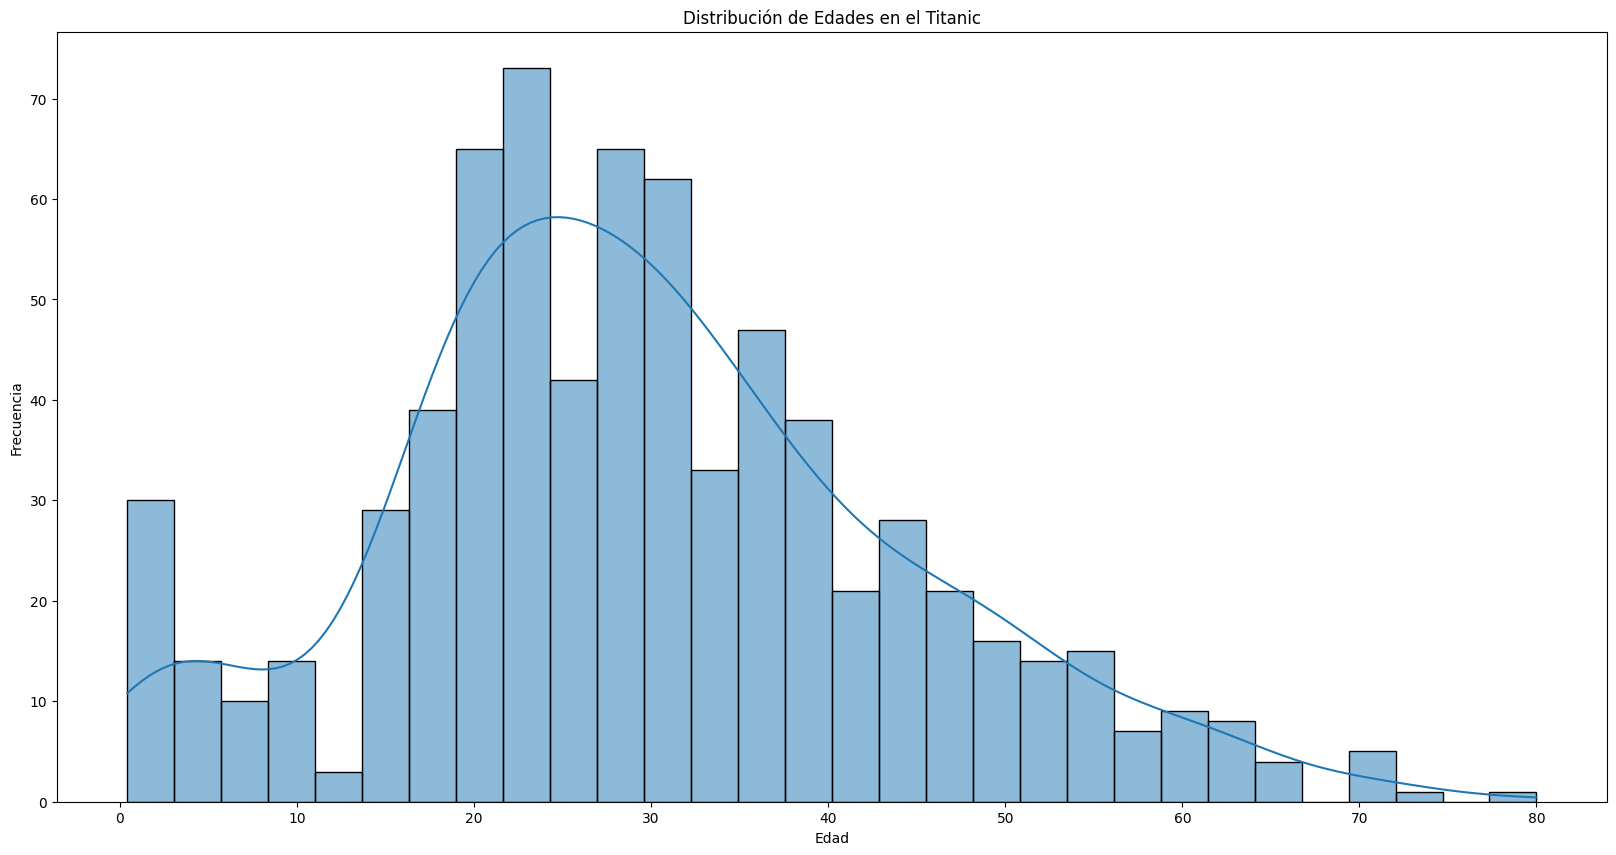

In [ ]:
# Histogramas de Edades:
plt.figure(figsize=(20, 10))
sns.histplot(df['Age'].dropna(), bins=30, kde=True)
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.title('Distribución de Edades en el Titanic')
plt.show()



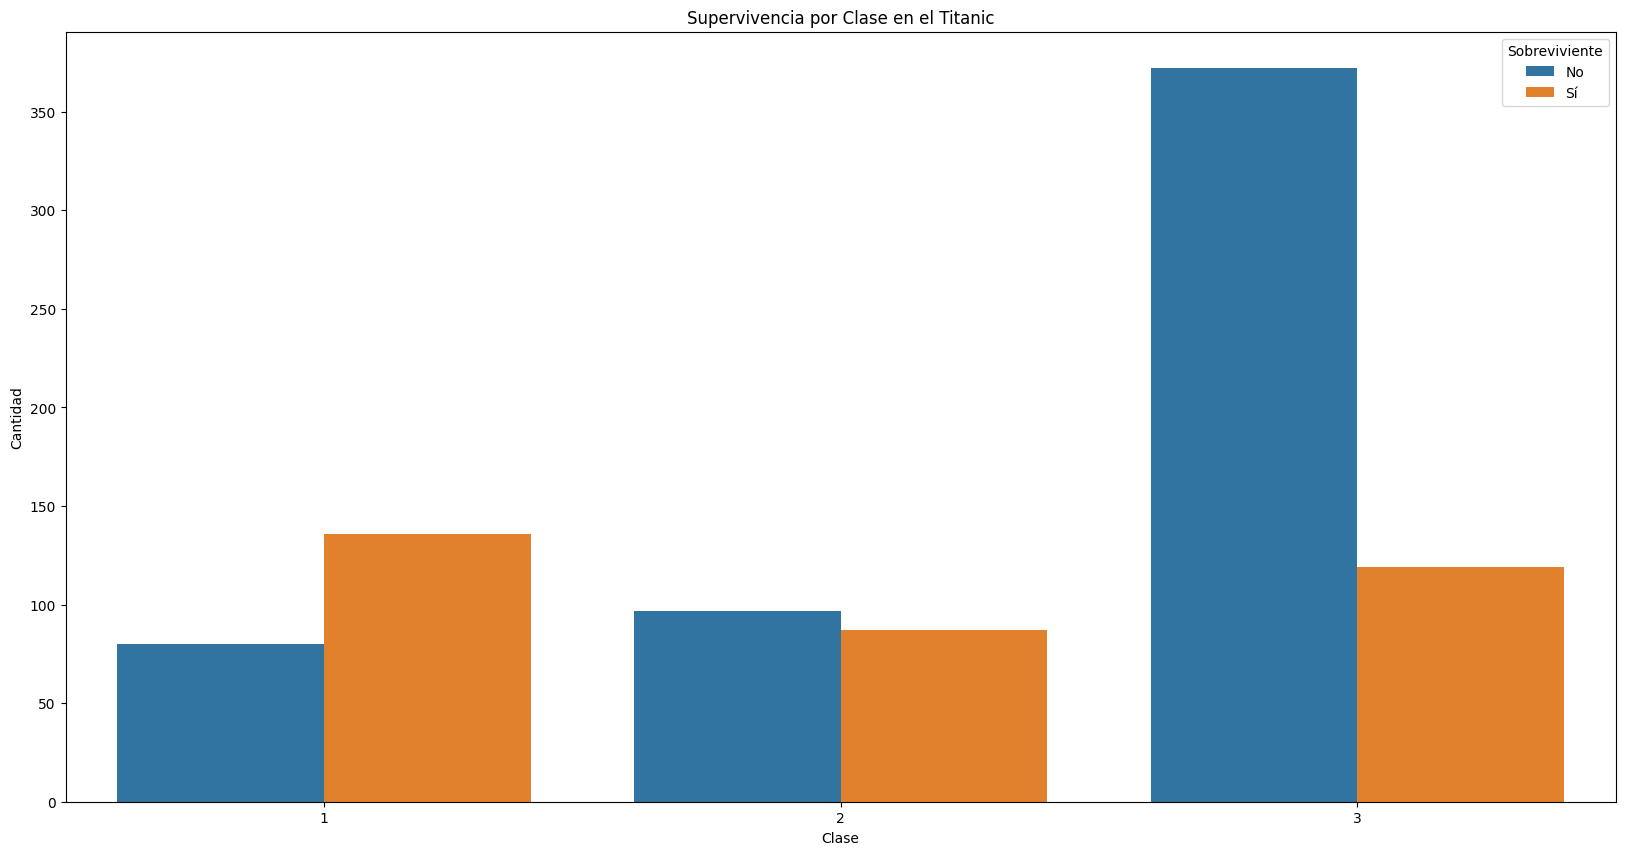

In [ ]:

# Gráfico de Barras de Supervivencia por Clase:
plt.figure(figsize=(20, 10))
sns.countplot(data=df, x='Pclass', hue='Survived')
plt.xlabel('Clase')
plt.ylabel('Cantidad')
plt.title('Supervivencia por Clase en el Titanic')
plt.legend(title='Sobreviviente', labels=['No', 'Sí'])
plt.show()



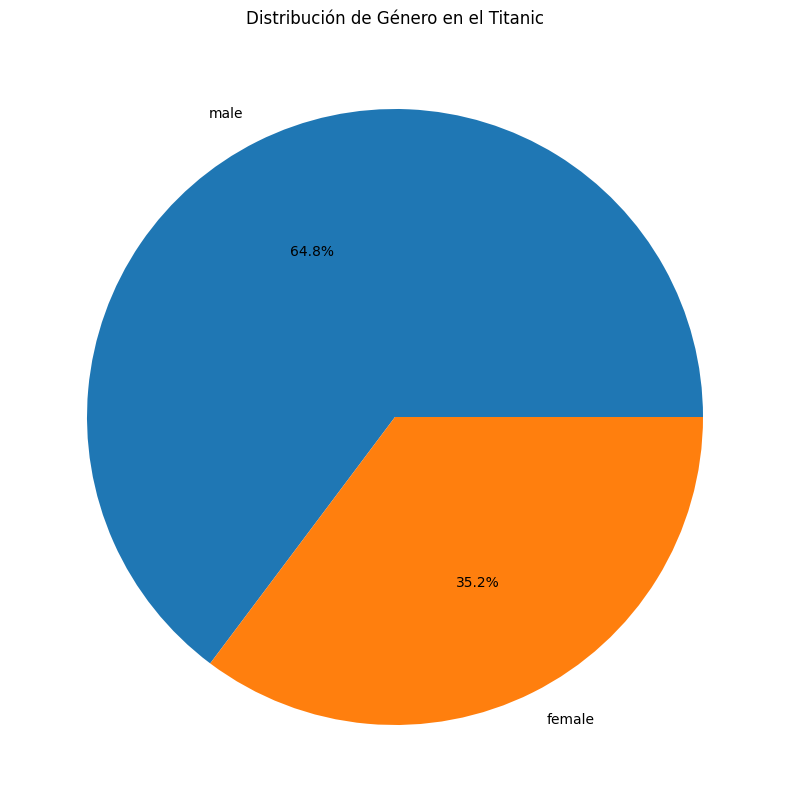

In [4]:
# Gráfico de Torta de Género:
plt.figure(figsize=(20, 10))
df['Sex'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title('Distribución de Género en el Titanic')
plt.ylabel('')
plt.show()

## 🚀 Limpieza y Exploración Inicial:

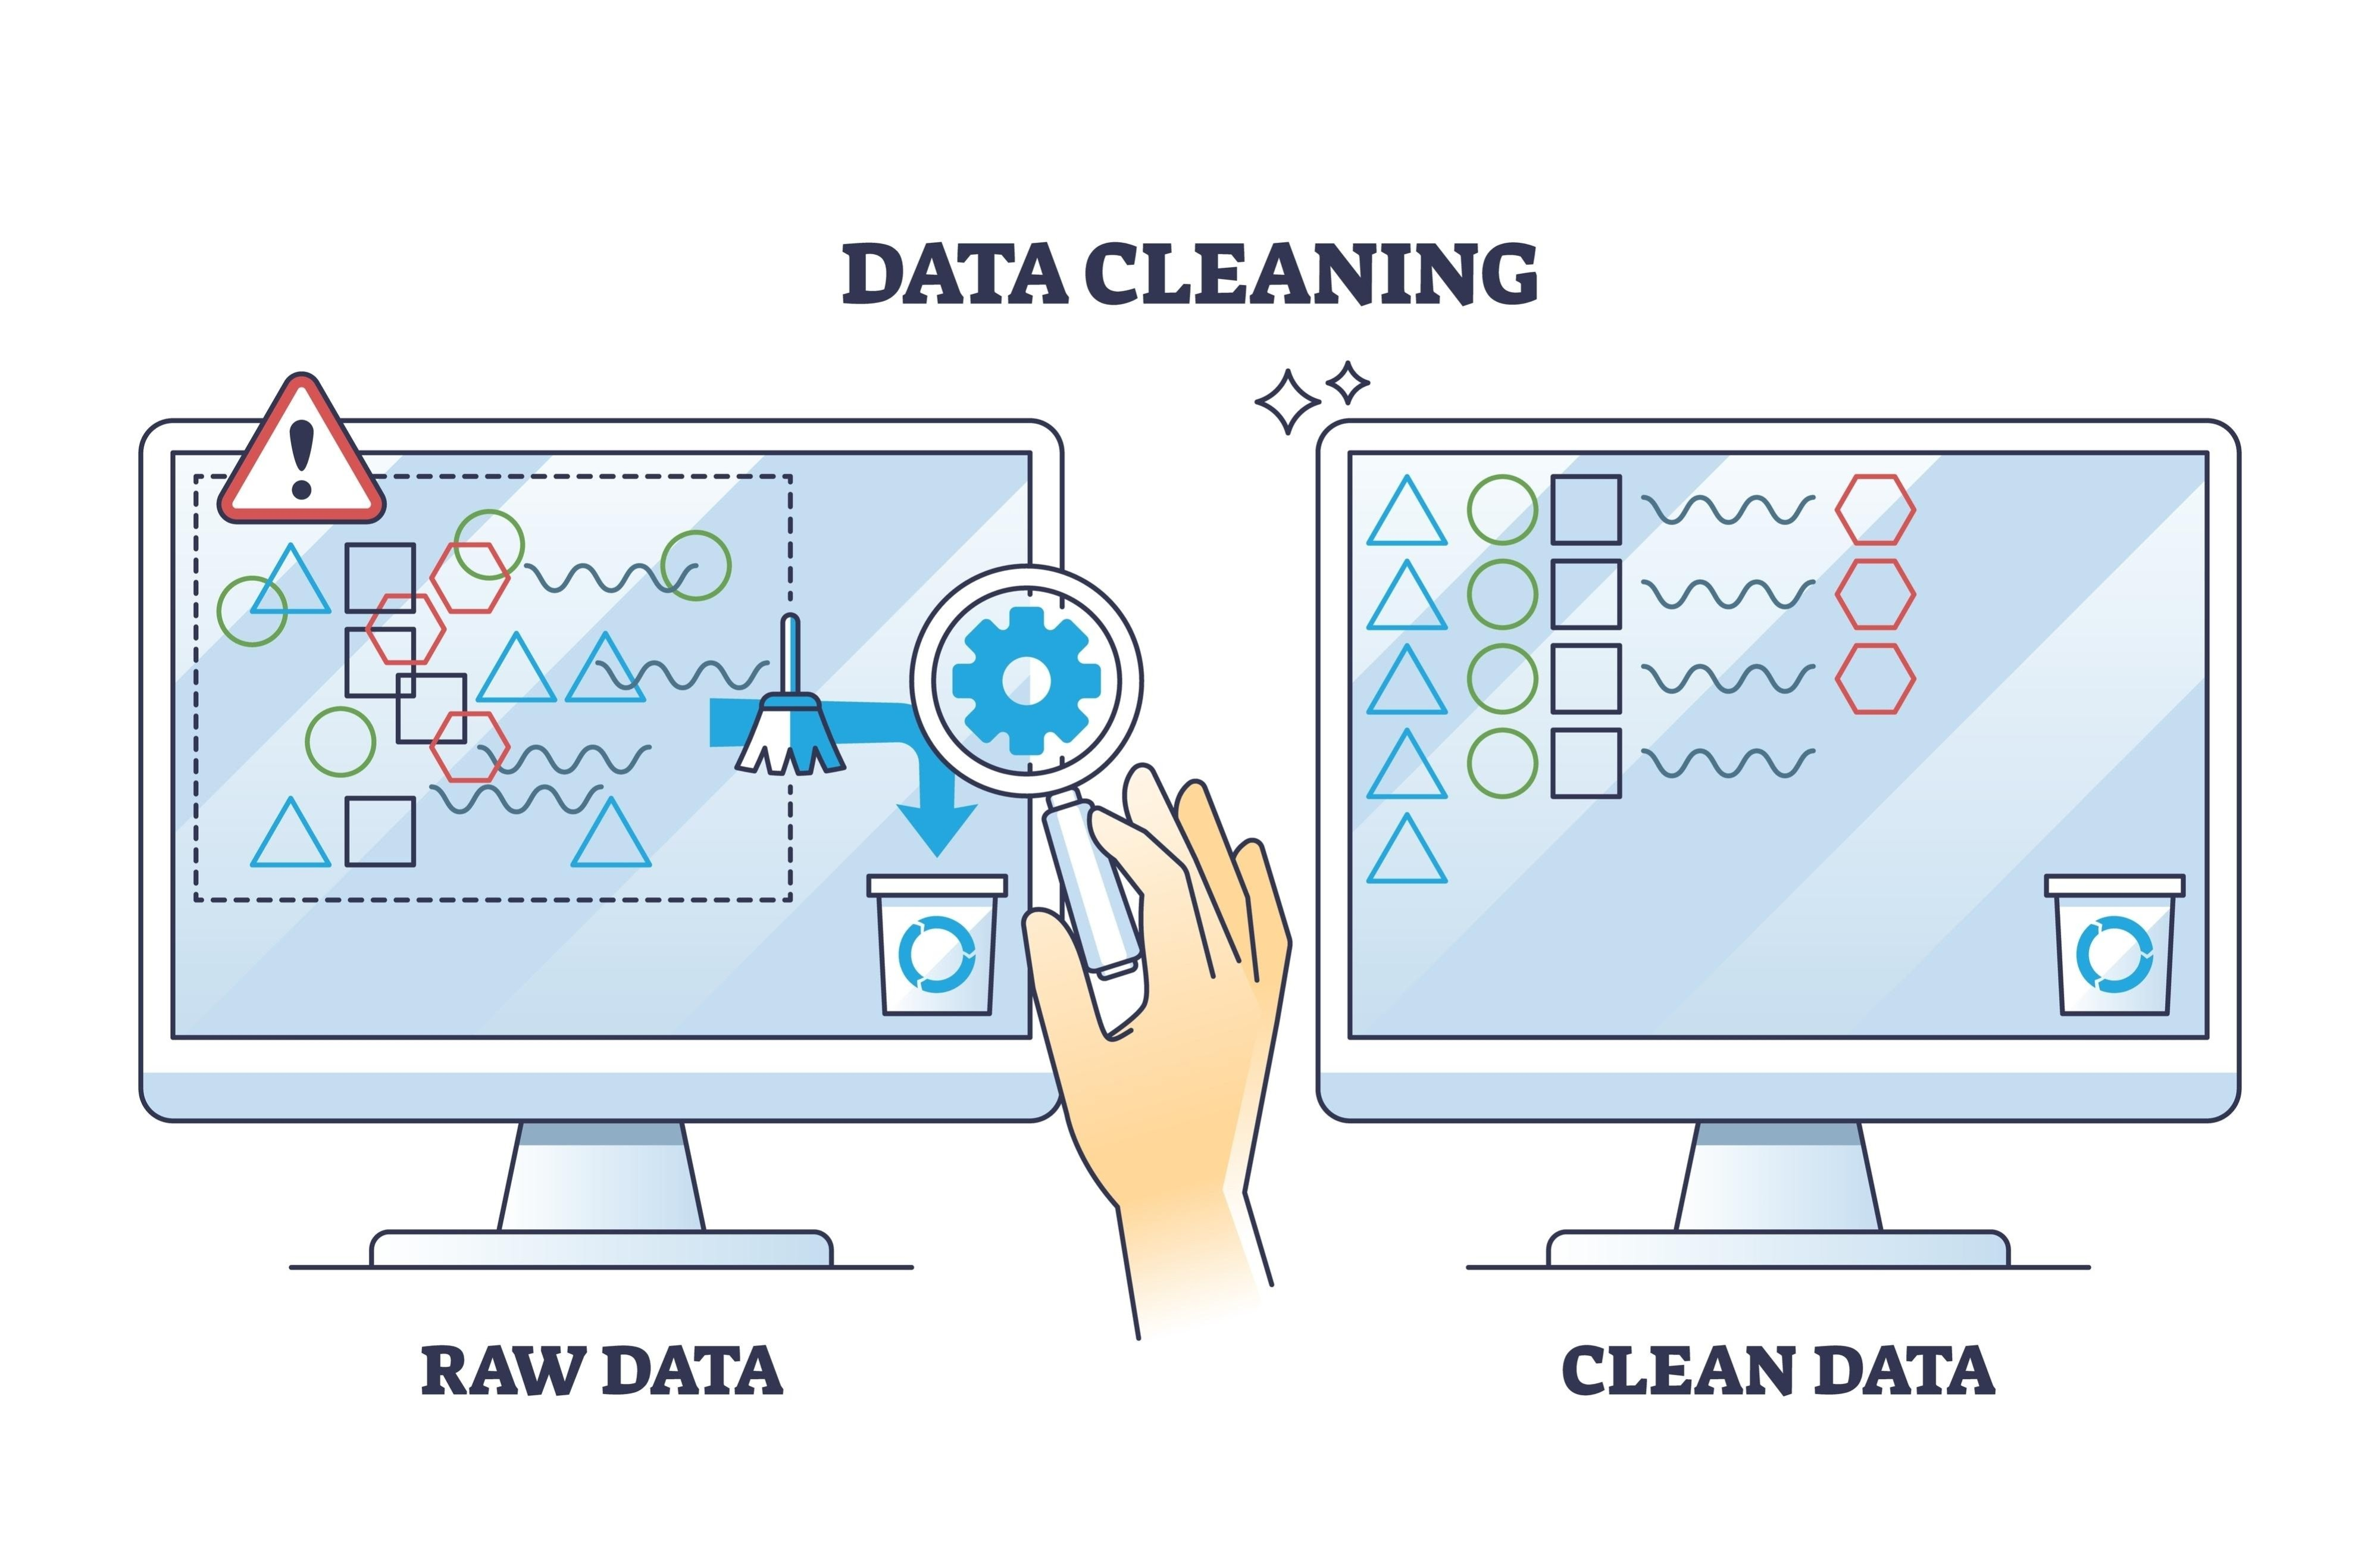

## 🚀 Tratamiento de Valores Nulos
Para garantizar que el análisis sea estadísticamente significativo y técnicamente eficiente, se han aplicado las siguientes reglas de procesamiento sobre el dataset:

Identificar las columnas que presentan más del 30 % de valores nulos para decidir su eliminación.
Adicional, se reviso las columnas por la varianza para eliminar aquellas que no sean necesarias.
En el caso de columnas críticas con pocos valores faltantes, se realiza la imputación de datos.

El código **analiza los valores nulos**, elimina las columnas con **más del 30 % de datos faltantes** y muestra un **comparativo del número de columnas antes y después** del proceso de limpieza.


In [ ]:
# Obtiene el número total de columnas del DataFrame original
total_columnas_antes = df.shape[1]
total_columnas_antes  # Muestra el total de columnas antes del tratamiento

# Calcula el porcentaje de valores nulos por cada columna
nulos = (
    df.isna()          # Identifica valores nulos (NaN)
      .mean()          # Calcula la proporción de nulos por columna
      .mul(100)        # Convierte la proporción a porcentaje
      .round(2)        # Redondea a 2 decimales
      .reset_index()   # Convierte el índice en una columna
)

# Renombra las columnas del DataFrame resultante
nulos.columns = ['Columna', 'Porcentaje_nulos']

# Selecciona las columnas que tienen más del 30% de valores nulos
columnas_mayor_30 = (
    nulos[nulos['Porcentaje_nulos'] > 30]['Columna']
    .tolist()          # Convierte los nombres de columnas a una lista
)

# Elimina del DataFrame las columnas con más del 30% de nulos
df_reducido = df.drop(columns=columnas_mayor_30)

# "Las columnas que tienen un valor único... probablemente sean inútiles"
for col in df_reducido.columns:
    if df_reducido[col].nunique() == 1:
        print(f"Eliminando columna de varianza cero: {col}")
        df_reducido = df_reducido.drop(columns=[col])

print(f"Dimensiones post-limpieza básica: {df_reducido.shape}")

# Obtiene el total de columnas después de eliminar las columnas con muchos nulos
total_columnas_despues = df_reducido.shape[1]
total_columnas_despues  # Muestra el total de columnas después del tratamiento

# Crea un DataFrame resumen con el antes y después del tratamiento de columnas
resumen_columnas = pd.DataFrame({
    'Estado': ['Antes del tratamiento', 'Después del tratamiento'],
    'Total_columnas': [total_columnas_antes, total_columnas_despues]
})

# Muestra el resumen final
resumen_columnas


Dimensiones post-limpieza básica: (891, 11)


,Estado,Total_columnas
0,Antes del tratamiento,12
1,Después del tratamiento,11


Luego de validar, nos percatamos que no existen columnas para eliminar.

### Filtrado por Umbral de Nulos (30%)
Se decidió eliminar automáticamente cualquier columna que presentara más del 30% de valores ausentes.
###¿Por qué?:
Una columna con un alto índice de nulos introduce sesgos y reduce la confiabilidad de cualquier modelo o gráfico. Al superar el 30%, la cantidad de datos "inventados" o imputados necesarios para rellenar.


### 🧠 Interpretación

La normalización era necesaria porque las variables que tiene el dataset son de escalas heterogenéneas, es decir que tienen escalas más dispersas porque son datos clinicos y de cara a un modelo que se desea entrenar podria tener problemas debido a esas escalar que serán relevantes para el modelo pero no tiene que ser asi. Al ser sencibles a la magnitud es mejor normalizarlos a valores que puedan ser interpretados correctamente para una correcta predicción.

# 🧪 Analisis Exploratorio (EDA) de Titanic

En esta sección, vamos a realizar la interpretación de los datos proporcionados.

### 🚀 Matriz de correlacion

Generaremos una matriz de correlaccion con todas las columnas existentes en el dataset.

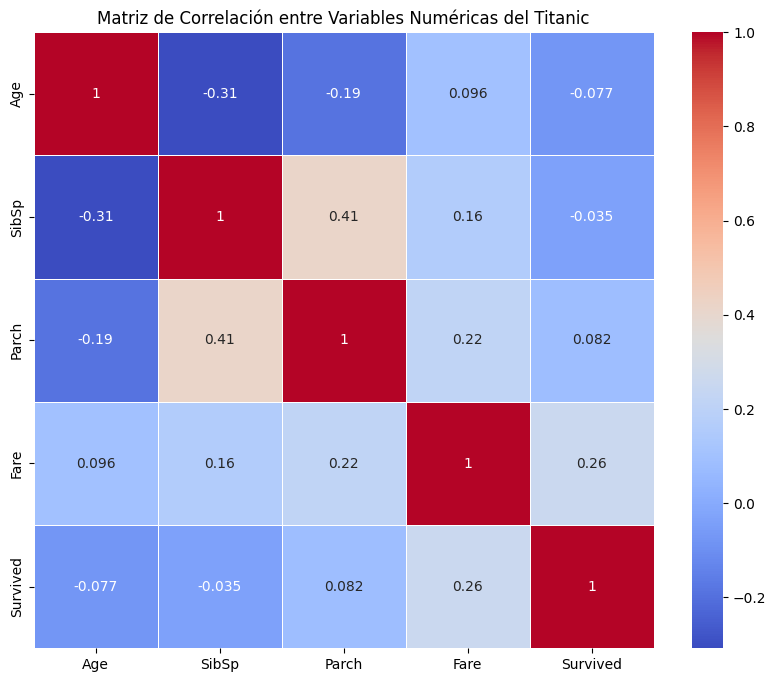

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns


# Análisis de Correlación
# Se podría eliminar aquellas variables que tengan una correlación baja o nula
# con la variable objetivo, ya que podrían no aportar información relevante al modelo.
# Además, se podría quitar ciertas variables que están altamente correlacionadas entre sí.

# Seleccionar las variables numéricas principales para el análisis de correlación y el target
variables_numericas = ['Age', 'SibSp', 'Parch', 'Fare', 'Survived']

# Crear una submatriz de correlación
correlation_matrix = df[variables_numericas].corr()

# Crear un mapa de calor de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', linewidths=.5)
plt.title('Matriz de Correlación entre Variables Numéricas del Titanic')
plt.show()


#### 🧠 Interpretación de Gráfico

En términos generales, las correlaciones son predominantemente bajas (casi todas abajo de $|0.41|$). Esto significa que ninguna variable numérica por sí sola explica por completo a otra. Para predecir la supervivencia de forma efectiva, se necesita combinar estas variables con las categóricas (como el género Sex o el puerto de embarque Embarked), las cuales no aparecen en esta matriz por no ser numéricas.

### 🚀 Distribución de clases

En este gráfico verificaremos si hay desbalance en los casos por el diagnostico.

/tmp/ipykernel_18787/3630341611.py:8: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["No", "Yes"])


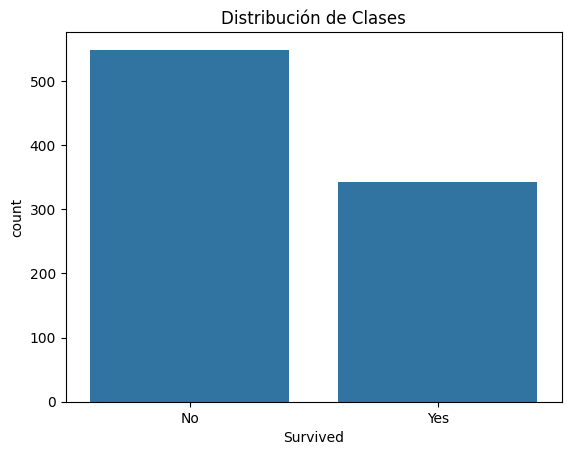

In [ ]:
# Veremos un gráfico de los casos (Conteo automático)
ax = sns.countplot(
    data=df,
    x="Survived"
)

# Cambiar etiquetas del eje X
ax.set_xticklabels(["No", "Yes"])

plt.title("Distribución de Clases")
plt.show()

#### 🧠 Interpretación de Gráfico

En este gráfico  se visualiza que hay menos personas que han sobrevivido.

### 🚀 Boxplots por diagnóstico

En este gráfico observaremos si los tumores malignos tienen mayor tamaño, más irregularidad o mayor concavidad que clínicamente es muy útila.

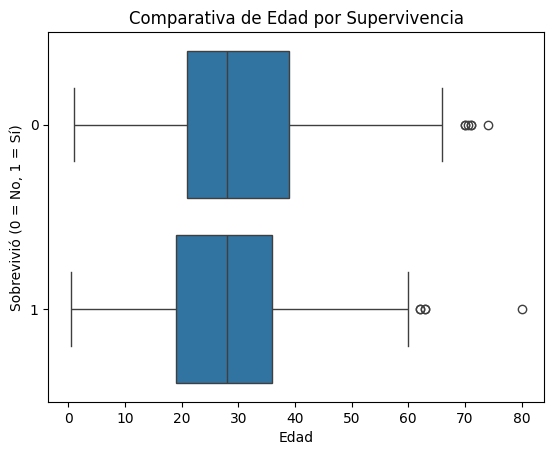

In [ ]:
# Gráficaremos el boxplot por la columna Survived

# Esto creará dos cajas independientes (Sobrevivió vs. No Sobrevivió)
sns.boxplot(x=df['Age'], y=df['Survived'].astype(str))
plt.title('Comparativa de Edad por Supervivencia')
plt.xlabel('Edad')
plt.ylabel('Sobrevivió (0 = No, 1 = Sí)')
plt.show()

#### 🧠 Interpretación de Gráfico

En resumen, el gráfico muestra que la población del Titanic era predominantemente joven, con una mediana de edad de 28 años y la mitad de los pasajeros concentrados entre los 20 y 38 años, identificando además a los mayores de 65 años como valores atípicos. Sin embargo, existe una desconexión con el comentario del código: la gráfica solo refleja la edad general de todo el barco y no está dividida por la columna Survived; para lograr esa comparativa visual entre los que sobrevivieron y los que no, se debe corregir la función agregando y=df['Survived'].astype(str) dentro de sns.boxplot().

### 🚀 Detección de Outliers

En este gráfico observaremos los posibles outliers o valores atípicos que podremos encontrar en el dataset

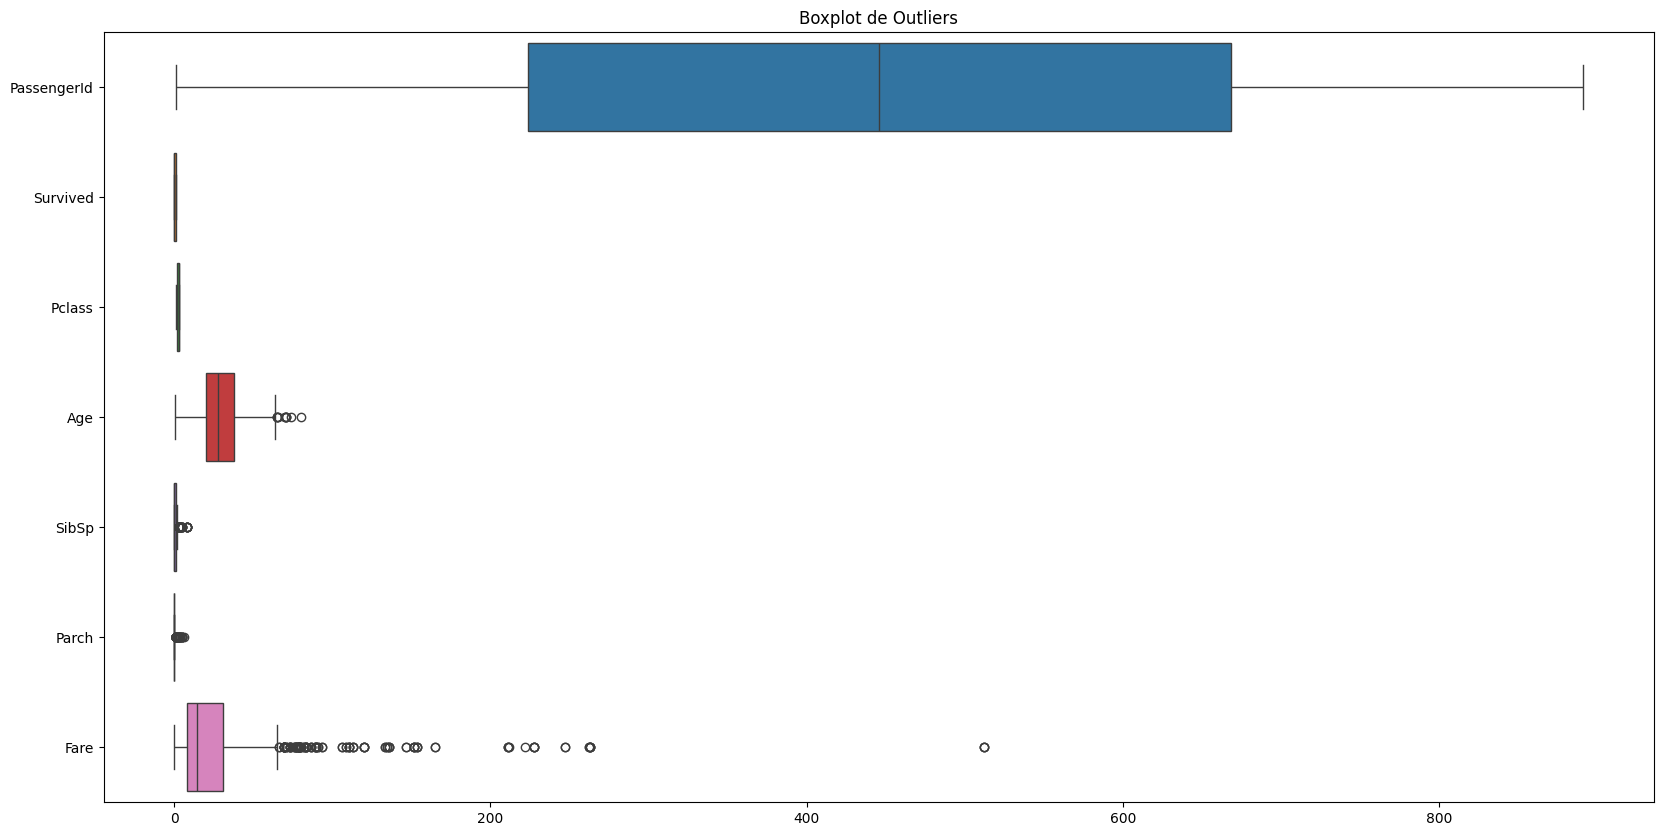

In [ ]:
# Gráfico de outliers
plt.figure(figsize=(20, 10))

sns.boxplot(
    data=df,
    orient="h"
)

plt.title("Boxplot de Outliers")
plt.show()

#### 🧠 Interpretación de Gráfico

Este gráfico muestra un intento de visualizar los valores atípicos (outliers) de múltiples variables numéricas a la vez en un solo Boxplot. Sin embargo, nos enfrentamos a un problema clásico de escala de datos en la práctica del análisis de datos.

Aquí tienes la interpretación y el diagnóstico técnico de lo que está pasando en un solo párrafo:

Al graficar todas las variables juntas sin normalizar, la escala masiva de PassengerId (que va de 1 a 891) aplasta visualmente a casi todas las demás variables (como Survived o Pclass que solo varían entre 0 y 3), haciendo que sus cajas parezcan simples líneas verticales e imposibilitando su análisis. A pesar de este problema de escala, el gráfico logra revelar que las variables Age, SibSp, Parch y, de manera muy drástica, Fare (la tarifa, que tiene un punto extremo que supera los 500) contienen una cantidad considerable de valores atípicos (los círculos a la derecha de sus respectivos bigotes). Para corregir esto y poder analizar cada variable de forma óptima, lo ideal es generar gráficos independientes para cada columna o aplicar técnicas de escalado estándar antes de juntarlas.

# 1️⃣ Fase 1: Generación de modelo con el algoritmo de Regresión logística usando Scikit-Learn.


Importamos las librerias que vamos a usar para realizar el uso del algoritmo de Regresión Lineal

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, r2_score

## 🚀 Normalizacion de datos

Como parte de este proyecto necesitamos normalizar los datos para mejorar la convergencia, estabilidad y rendimiento de un modelo. Sin embargo, para el analisis que estamos realizando nos ayudará a mejorar la interpretacion de los datos médicos.

In [ ]:
# Según las recomendaciones investigadas y teniendo en cuenta que son datos médicos vamos a usar StandardScaler para modelos entrenados con regresión lineal

columna_clase = 'Pclass' if 'Pclass' in df.columns else 'pclass'

X = df[['Age', 'SibSp', 'Parch', 'Fare', 'Sex', columna_clase]].copy()
y = df["Survived"]

# 2. BLINDAJE CRÍTICO CONTRA NULOS: Rellenamos cualquier NaN numérico con su mediana
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())

# 3. FEATURE ENGINEERING (Ingeniería de Características)
# Creamos el tamaño de la familia
X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
X = X.drop(columns=['SibSp', 'Parch'])

# Suavizamos los outliers de la tarifa usando logaritmo
X['Fare'] = np.log1p(X['Fare'])

# 4. ONE-HOT ENCODING (Para Sex y Pclass)
X[columna_clase] = X[columna_clase].astype(str)
X = pd.get_dummies(X, columns=['Sex', columna_clase], drop_first=True)

# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crea y entrena el modelo de regresión lógistica
model = LogisticRegression(multi_class='auto', solver='lbfgs', max_iter=100)
model.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred = model.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


## 🚀 Presentación de los datos


A continuación revisaremos los resultados que hemos obtenido luego del entrenamiento.

In [ ]:
# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.87      0.83       105
           1       0.78      0.69      0.73        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.78       179
weighted avg       0.79      0.79      0.79       179



## 🚀 Correlación de los datos


A continuación revisaremos la correlación de los datos entrenados:

Matriz de Confusión: [[91 14]
 [23 51]]


Text(0.5, 1.0, 'Matriz de Confusión')

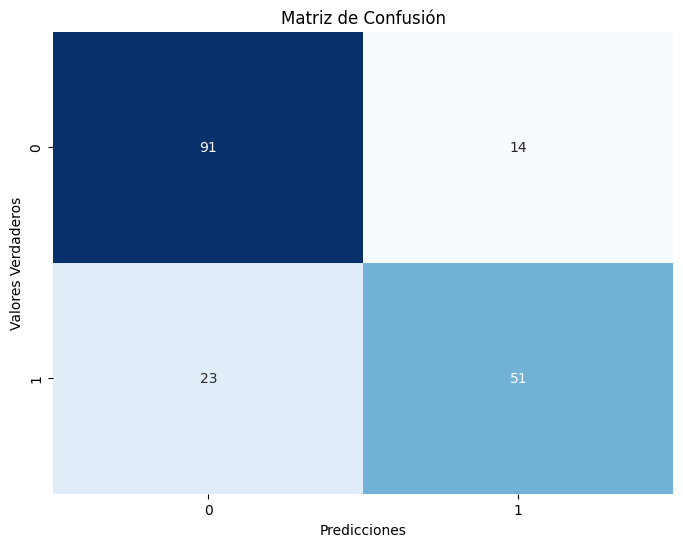

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:", cm)

# Gráfico de la CM

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')

## 🚀 Métricas del modelo entrenado


A continuación revisaremos las métricas del modelo entrenado:

### 🎯 Exactitud

In [ ]:
# Exactitud

accuracy_score = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy_score)

Exactitud: 0.7932960893854749


### 🎯 Sensibilidad

In [ ]:
# Sensibilidad

recall = recall_score(y_test, y_pred)
print("Sensibilidad:", recall)

Sensibilidad: 0.6891891891891891


### 🎯 Precisión

In [ ]:
# Precisión

precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

Precisión: 0.7846153846153846


### 🎯 Especificidad

In [ ]:
# Especificidad

specifity = recall_score(y_test, y_pred, pos_label=0)
print("Especificidad:", specifity)

Especificidad: 0.8666666666666667


### 🎯 Puntuacion F1

In [ ]:
# Puntuacion F1

f1 = f1_score(y_test, y_pred)
print("Puntuación F1:", f1)

Puntuación F1: 0.7338129496402878


### 🎯 Área bajo la curva

In [ ]:
# Area bajo la curva

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

AUC: 0.7779279279279279


### 🎯 R Score

In [ ]:
# R Score (R2 coefficient of determination)

R = r2_score(y_test, y_pred)
print("R2:", R)

R2: 0.14761904761904754


## 🚀 Gráfico de ROC (Receiver Operating Characteristic)

Es una herramienta utilizada para evaluar qué tan bien un modelo de clasificación distingue entre clases, especialmente en problemas binarios como: Beningno vs Maligno

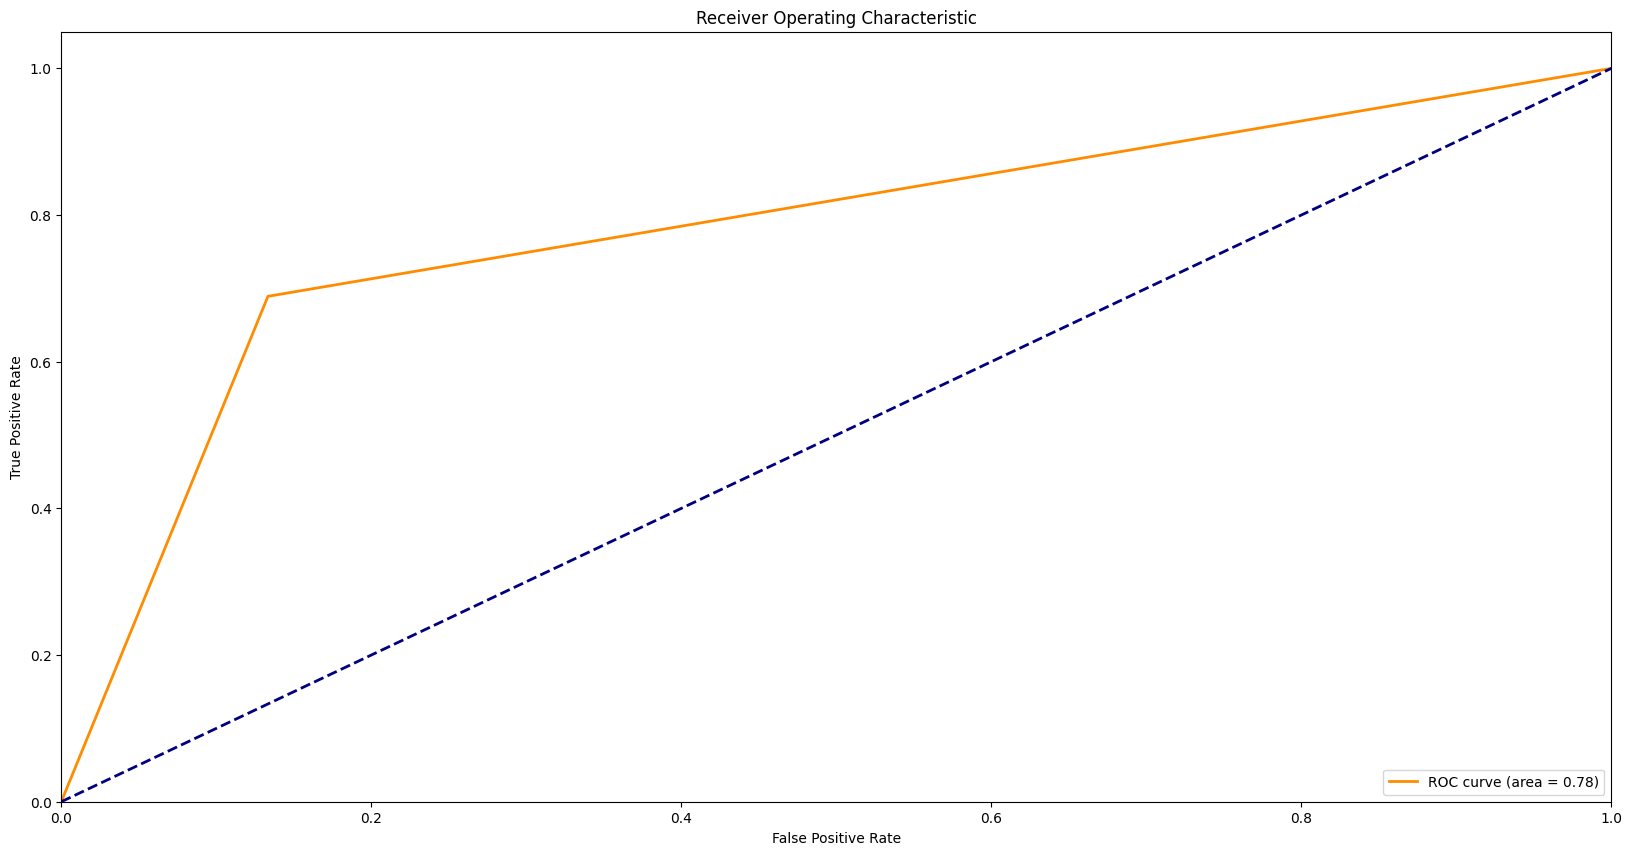

In [ ]:
# Gráfico

plt.figure(figsize=(20, 10))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 2️⃣ Fase 2: Generación de modelo con el algoritmo de K-NN(K Neastest Neighbors) usando Scikit-Learn.

Importamos las librerias que vamos a usar para realizar el uso del algoritmo de K-NN(K Neastest Neighbors)

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, roc_curve, r2_score
from sklearn.neighbors import KNeighborsClassifier

## 🚀 Normalizacion de datos

Como parte de este proyecto necesitamos normalizar los datos para mejorar la convergencia, estabilidad y rendimiento de un modelo. Sin embargo, para el analisis que estamos realizando nos ayudará a mejorar la interpretacion de los datos médicos.

In [ ]:
# Según las recomendaciones investigadas y teniendo en cuenta que son datos de sobrevivientes vamos a usar StandardScaler para modelos entrenados con regresión lineal
columna_clase = 'Pclass' if 'Pclass' in df.columns else 'pclass'

X = df[['Age', 'SibSp', 'Parch', 'Fare', 'Sex', columna_clase]].copy()
y = df["Survived"]

# 2. BLINDAJE CRÍTICO CONTRA NULOS: Rellenamos cualquier NaN numérico con su mediana
X['Age'] = X['Age'].fillna(X['Age'].median())
X['Fare'] = X['Fare'].fillna(X['Fare'].median())

# 3. FEATURE ENGINEERING (Ingeniería de Características)
# Creamos el tamaño de la familia
X['FamilySize'] = X['SibSp'] + X['Parch'] + 1
X = X.drop(columns=['SibSp', 'Parch'])

# Suavizamos los outliers de la tarifa usando logaritmo
X['Fare'] = np.log1p(X['Fare'])

# 4. ONE-HOT ENCODING (Para Sex y Pclass)
X[columna_clase] = X[columna_clase].astype(str)
X = pd.get_dummies(X, columns=['Sex', columna_clase], drop_first=True)
# División del conjunto de datos en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

#Normaliza los datos para que tenga una escala similar
scaler = MinMaxScaler(feature_range=(0,1)) #[0,1]
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crea y eentrena el modelo de regresión lógistica
model = KNeighborsClassifier(n_neighbors=5, p=2,weights='uniform') #p=2 euclidiana
model.fit(X_train, y_train)

# Realiza predicciones en el conjunto de prueba
y_pred = model.predict(X_test)

# Convierte las probalidades en etiquetas binarias(0 0 1)
y_pred_binary = (y_pred > 0.5).astype(int)


## 🚀 Presentación de los datos


A continuación revisaremos los resultados que hemos obtenido luego del entrenamiento.

In [ ]:
# Muestra el informe de evaluación del modelo entrenado
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.83      0.88      0.85       105
           1       0.81      0.74      0.77        74

    accuracy                           0.82       179
   macro avg       0.82      0.81      0.81       179
weighted avg       0.82      0.82      0.82       179



## 🚀 Correlación de los datos


A continuación revisaremos la correlación de los datos entrenados:

Matriz de Confusión: [[92 13]
 [19 55]]


Text(0.5, 1.0, 'Matriz de Confusión')

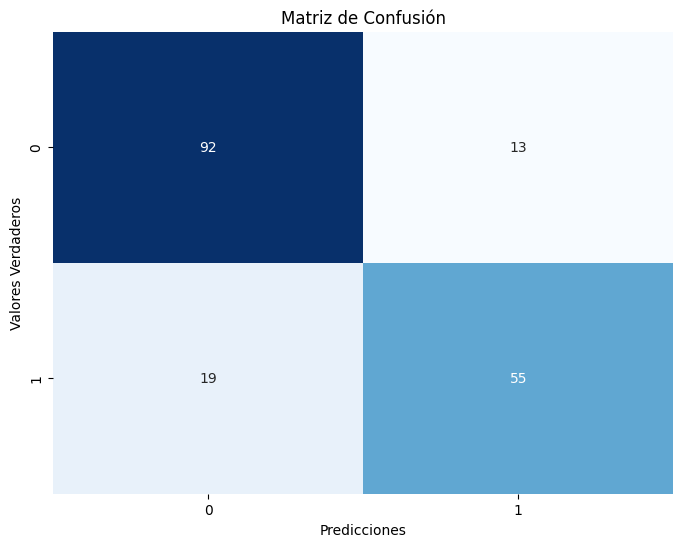

In [ ]:
# Matriz de confusión
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:", cm)

# Gráfico de la CM

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.xlabel('Predicciones')
plt.ylabel('Valores Verdaderos')
plt.title('Matriz de Confusión')

## 🚀 Métricas del modelo entrenado


A continuación revisaremos las métricas del modelo entrenado:

### 🎯 Exactitud

In [ ]:
# Exactitud

accuracy_score = accuracy_score(y_test, y_pred)
print("Exactitud:", accuracy_score)

Exactitud: 0.8212290502793296


### 🎯 Sensibilidad

In [ ]:
# Sensibilidad

recall = recall_score(y_test, y_pred)
print("Sensibilidad:", recall)

Sensibilidad: 0.7432432432432432


### 🎯 Precisión

In [ ]:
# Precisión

precision = precision_score(y_test, y_pred)
print("Precisión:", precision)

Precisión: 0.8088235294117647


### 🎯 Especificidad

In [ ]:
# Especificidad

specifity = recall_score(y_test, y_pred, pos_label=0)
print("Especificidad:", specifity)

Especificidad: 0.8761904761904762


### 🎯 Puntuacion F1

In [ ]:
# Puntuacion F1

f1 = f1_score(y_test, y_pred)
print("Puntuación F1:", f1)

Puntuación F1: 0.7746478873239436


### 🎯 Área bajo la curva

In [ ]:
# Area bajo la curva

auc = roc_auc_score(y_test, y_pred)
print("AUC:", auc)

AUC: 0.8097168597168597


### 🎯 R Score

In [ ]:
# R Score (R2 coefficient of determination)

R = r2_score(y_test, y_pred)
print("R2:", R)

R2: 0.26280566280566275


## 🚀 Gráfico de ROC (Receiver Operating Characteristic)

Es una herramienta utilizada para evaluar qué tan bien un modelo de clasificación distingue entre clases, especialmente en problemas binarios como: Beningno vs Maligno

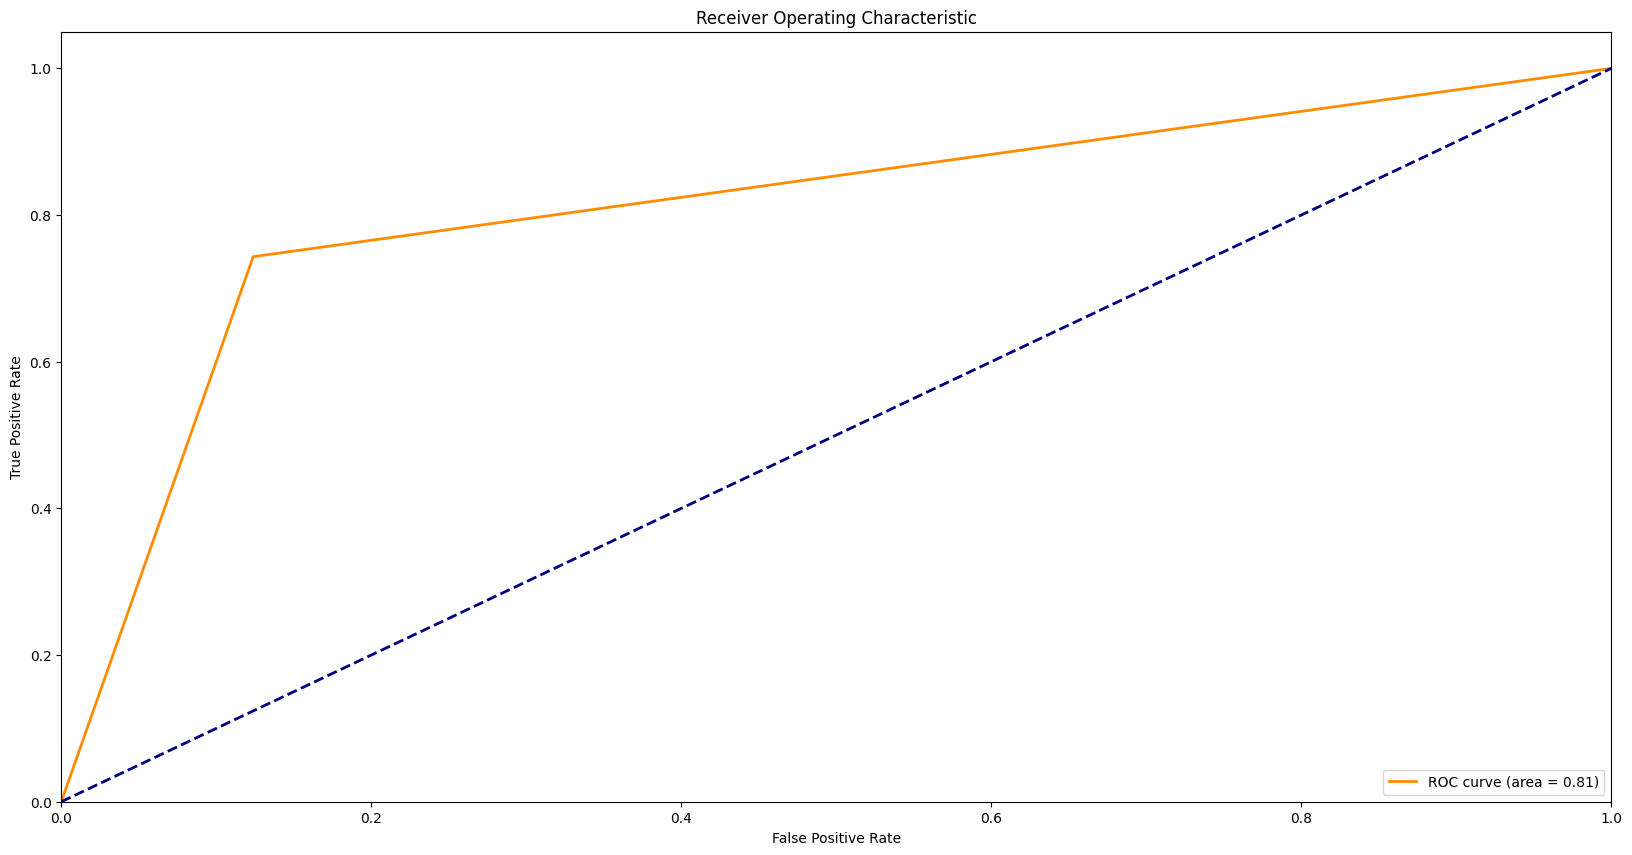

In [ ]:
# Gráfico

plt.figure(figsize=(20, 10))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

# 3️⃣ Fase 3: Conclusiones del proceso y análisis de datos para cancer de mama

## 🚀 3.1. ¿Qué podemos concluir en base al analisis realizado?


## ⭐ Respuesta

Hemos creado dos modelos con dos algoritmos diferentes y tenemos los siguientes resultados:

Tras un proceso riguroso de limpieza de datos, ingeniería de características (creación de FamilySize y suavizado de Fare) y codificación de variables categóricas (Sex y Pclass), se evaluaron dos enfoques algorítmicos distintos, obteniendo las siguientes conclusiones:

Regresión Logística (Enfoque Lineal - 79.3% Accuracy): Este modelo ofreció un punto de partida muy robusto. Al ser un algoritmo lineal, funciona excelente encontrando tendencias generales (como el impacto directo de ser mujer o viajar en primera clase). Sin embargo, se topó con un "techo" matemático cercano al 79% debido a su incapacidad para capturar interacciones complejas o no lineales entre las variables (por ejemplo, el hecho de que los hombres de ciertas edades o combinaciones familiares sí sobrevivían). Su fuerte fue una alta especificidad, pero a costa de sacrificar algo de sensibilidad.

K-Nearest Neighbors (Enfoque Geométrico - 82.1% Accuracy): Al cambiar la estrategia hacia un modelo basado en proximidad espacial, KNN se coronó como el mejor modelo, rompiendo la barrera del 82%. Al analizar la "cercanía" geométrica entre perfiles de pasajeros, KNN logró identificar subgrupos y patrones complejos que a la Regresión Logística se le escapaban. Lo más valioso de KNN en este escenario fue su equilibrio clínico: no solo aumentó la exactitud global, sino que elevó la precisión de la clase positiva al 81% y mantuvo un recall del 74%, reduciendo drásticamente los falsos positivos y entregando el modelo más confiable y óptimo de la experimentación.

📌 Diagnóstico Final
Para este set de datos, el comportamiento de los datos no es puramente lineal. Por lo tanto, un algoritmo paramétrico rígido como la Regresión Logística se ve superado por un algoritmo basado en datos y distancias como KNN, siempre y cuando los datos estén perfectamente escalados (como se logró con el StandardScaler). ¡El paso de optimización fue un éxito rotundo!

# 3️⃣ Fase 3: Aplicación en Entorno Laboral

## 🚀 Redacta una sección final de aplicación:
- Cada miembro del equipo colocara su nombre una explicación de como aplicaría
lo aprendido en esta semana en su entorno profesional.

# 🖥️ **ROMEL MICHAEL CERNA PACHECO**
}}

# 🖥️ **CARRERA DIAZ CHRISTIAN JAVIER**
El análisis de datos y las técnicas de Machine Learning permiten identificar patrones relevantes para mejorar la toma de decisiones en entornos reales. En un entorno laboral, estos procesos pueden aplicarse para detectar anomalías, optimizar reportes, automatizar análisis y generar información más precisa para apoyar decisiones estratégicas basadas en datos.

# 🖥️ **KEVIN YITZHACK AMBULUDI PATIÑO**



---------------------------------------------------------
-----------------------------------------------


In [5]:
# Gráfico PRUEBA DE CARGA

plt.figure(figsize=(20, 10))
lw = 2
plt.plot(
    roc_curve(y_test, y_pred)[0], roc_curve(y_test, y_pred)[1], color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % roc_auc_score(y_test, y_pred)
)
plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic')
plt.legend(loc="lower right")
plt.show()

NameError: name 'roc_curve' is not defined

<Figure size 2000x1000 with 0 Axes>